<a href="https://colab.research.google.com/github/shankar27git/Spectral-Alignment-Info-Bottleneck-in-Variational-Quantum-Maps-on-Synthetic-Manifolds/blob/main/Spectral_Alignment_%26_Info_Bottleneck_in_Variational_Quantum_Maps_on_Synthetic_Manifolds_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install yfinance ta scikit-learn matplotlib seaborn --quiet

  Preparing metadata (setup.py) ... done


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
tickers = ["AAPL", "AMZN", "META", "NFLX", "GOOGL"]

raw_data = yf.download(
    tickers,
    period="10y",
    interval="1d",
    group_by="ticker",
    auto_adjust=True
)

raw_data.head()

[*********************100%***********************]  5 of 5 completed


Ticker           AMZN                                                   AAPL  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2016-02-24  27.287500  27.713499  26.657499  27.702000  124634000  21.284631   
2016-02-25  27.775999  27.969500  27.264500  27.757500   90510000  21.753450   
2016-02-26  28.006001  28.125000  27.658501  27.761499   97540000  22.013903   
2016-02-29  27.700001  28.240499  27.625500  27.625999   82908000  21.936899   
2016-03-01  27.814501  28.962500  27.799999  28.952000  100770000  22.115813   

Ticker                                                  ...        META  \
Price            High        Low      Close     Volume  ...        Open   
Date                                                    ...               
2016-02-24  21.828183  21.135153  21.764769  145022800  ...  103.487111   
2016-02-25  21.914251  21.572265  21.914251  110330800  ...  106.366988   
2016-02-26  22.199617  21.873486  21.948225  115964400  ...  107.945959   
2016-02-29  22.247178  21.889338  21.898397  140865200  ...  106.853582   
2016-03-01  22.822431  22.063722  22.768076  201628400  ...  107.082003   

Ticker                                                        GOOGL  \
Price             High         Low       Close    Volume       Open   
Date                                                                  
2016-02-24  106.208102  102.027307  106.138588  34412400  35.264055   
2016-02-25  107.320328  104.877393  107.320328  29906300  35.875436   
2016-02-26  108.690757  106.416649  107.171371  26686200  36.404930   
2016-02-29  108.154500  106.009480  106.178299  32779000  35.779657   
2016-03-01  109.058197  106.853596  109.058197  26817300  35.794546   

Ticker                                                 
Price            High        Low      Close    Volume  
Date                                                   
2016-02-24  35.790579  34.837779  35.774696  37092000  
2016-02-25  36.201968  35.394073  36.182617  36146000  
2016-02-26  36.531968  35.826302  35.971207  42474000  
2016-02-29  36.256057  35.573217  35.592075  45068000  
2016-03-01  36.838163  35.662543  36.830223  60112000  

[5 rows x 25 columns]

In [ ]:
tickers = ["AAPL", "AMZN", "META", "NFLX", "GOOGL"]

raw_data = yf.download(
    tickers,
    period="10y",
    interval="1d",
    group_by="ticker",
    auto_adjust=True
)

raw_data.head()

[*********************100%***********************]  5 of 5 completed


Ticker           AMZN                                                   AAPL  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2016-02-24  27.287500  27.713499  26.657499  27.702000  124634000  21.284637   
2016-02-25  27.775999  27.969500  27.264500  27.757500   90510000  21.753445   
2016-02-26  28.006001  28.125000  27.658501  27.761499   97540000  22.013901   
2016-02-29  27.700001  28.240499  27.625500  27.625999   82908000  21.936897   
2016-03-01  27.814501  28.962500  27.799999  28.952000  100770000  22.115822   

Ticker                                                  ...        META  \
Price            High        Low      Close     Volume  ...        Open   
Date                                                    ...               
2016-02-24  21.828189  21.135159  21.764774  145022800  ...  103.487104   
2016-02-25  21.914246  21.572260  21.914246  110330800  ...  106.366988   
2016-02-26  22.199615  21.873484  21.948223  115964400  ...  107.945959   
2016-02-29  22.247176  21.889336  21.898396  140865200  ...  106.853582   
2016-03-01  22.822440  22.063731  22.768085  201628400  ...  107.081988   

Ticker                                                        GOOGL  \
Price             High         Low       Close    Volume       Open   
Date                                                                  
2016-02-24  106.208094  102.027300  106.138580  34412400  35.264055   
2016-02-25  107.320328  104.877393  107.320328  29906300  35.875436   
2016-02-26  108.690757  106.416649  107.171371  26686200  36.404930   
2016-02-29  108.154500  106.009480  106.178299  32779000  35.779661   
2016-03-01  109.058182  106.853581  109.058182  26817300  35.794546   

Ticker                                                 
Price            High        Low      Close    Volume  
Date                                                   
2016-02-24  35.790579  34.837779  35.774696  37092000  
2016-02-25  36.201968  35.394073  36.182617  36146000  
2016-02-26  36.531968  35.826302  35.971207  42474000  
2016-02-29  36.256061  35.573221  35.592079  45068000  
2016-03-01  36.838163  35.662543  36.830223  60112000  

[5 rows x 25 columns]

In [ ]:
dfs = []

for ticker in tickers:
    temp = raw_data[ticker].copy()
    temp.reset_index(inplace=True)
    temp["Symbol"] = ticker
    dfs.append(temp)

df = pd.concat(dfs)
df.sort_values(["Symbol", "Date"], inplace=True)
df.head()

Price,Date,Open,High,Low,Close,Volume,Symbol
0,2016-02-24,21.284637,21.828189,21.135159,21.764774,145022800,AAPL
1,2016-02-25,21.753445,21.914246,21.572260,21.914246,110330800,AAPL
2,2016-02-26,22.013901,22.199615,21.873484,21.948223,115964400,AAPL
3,2016-02-29,21.936897,22.247176,21.889336,21.898396,140865200,AAPL
4,2016-03-01,22.115822,22.822440,22.063731,22.768085,201628400,AAPL


In [ ]:
def add_indicators(data):
    data["RSI"] = ta.momentum.RSIIndicator(data["Close"]).rsi()
    data["EMA_20"] = ta.trend.EMAIndicator(data["Close"], window=20).ema_indicator()
    data["EMA_50"] = ta.trend.EMAIndicator(data["Close"], window=50).ema_indicator()

    macd = ta.trend.MACD(data["Close"])
    data["MACD"] = macd.macd()
    data["MACD_Signal"] = macd.macd_signal()

    return data

df = df.groupby("Symbol", group_keys=False).apply(add_indicators)
df.dropna(inplace=True)

df.head()

/tmp/ipython-input-505948768.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Symbol", group_keys=False).apply(add_indicators)


Price,Date,Open,High,Low,Close,Volume,Symbol,RSI,EMA_20,EMA_50,MACD,MACD_Signal
49,2016-05-04,21.560937,21.719475,21.248395,21.332193,164102000,AAPL,25.650392,23.003057,23.263528,-0.720819,-0.346011
50,2016-05-05,21.418781,21.434731,21.118007,21.245607,143562000,AAPL,25.086668,22.835681,23.184394,-0.764956,-0.429800
51,2016-05-06,21.275234,21.293461,20.928886,21.127125,174799600,AAPL,24.299686,22.672961,23.103717,-0.800270,-0.503894
52,2016-05-09,21.190922,21.366373,21.097499,21.143072,131745600,AAPL,24.642349,22.527258,23.026829,-0.817546,-0.566624
53,2016-05-10,21.266116,21.320802,20.988128,21.286623,134747200,AAPL,27.810082,22.409102,22.958585,-0.810314,-0.615362


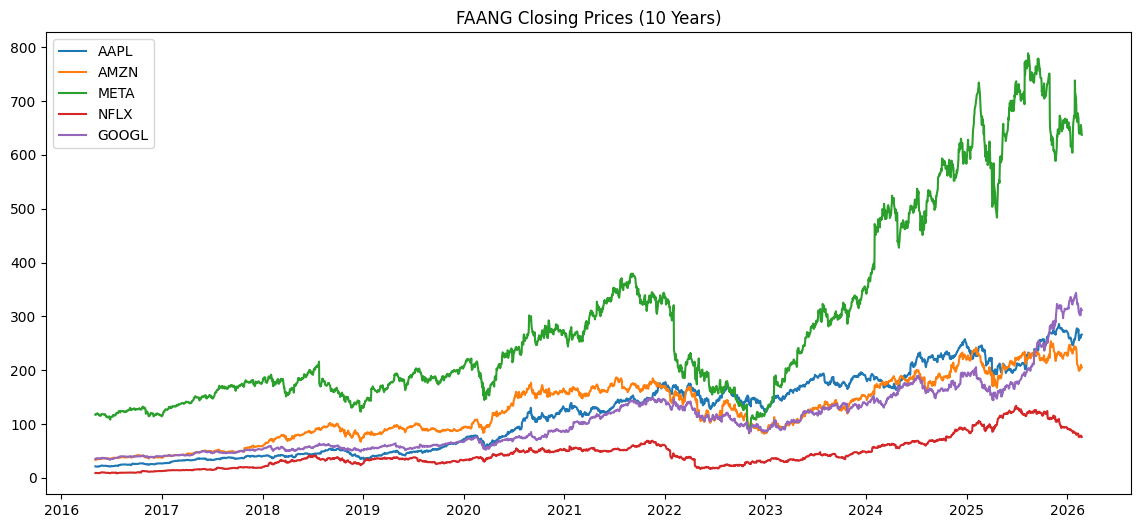

In [ ]:
plt.figure(figsize=(14,6))

for ticker in tickers:
    subset = df[df["Symbol"] == ticker]
    plt.plot(subset["Date"], subset["Close"], label=ticker)

plt.title("FAANG Closing Prices (10 Years)")
plt.legend()
plt.show()

In [ ]:
df["Next_Close"] = df.groupby("Symbol")["Close"].shift(-1)
df.dropna(inplace=True)

df.head()

Price,Date,Open,High,Low,Close,Volume,Symbol,RSI,EMA_20,EMA_50,MACD,MACD_Signal,Next_Close
49,2016-05-04,21.560937,21.719475,21.248395,21.332193,164102000,AAPL,25.650392,23.003057,23.263528,-0.720819,-0.346011,21.245607
50,2016-05-05,21.418781,21.434731,21.118007,21.245607,143562000,AAPL,25.086668,22.835681,23.184394,-0.764956,-0.429800,21.127125
51,2016-05-06,21.275234,21.293461,20.928886,21.127125,174799600,AAPL,24.299686,22.672961,23.103717,-0.800270,-0.503894,21.143072
52,2016-05-09,21.190922,21.366373,21.097499,21.143072,131745600,AAPL,24.642349,22.527258,23.026829,-0.817546,-0.566624,21.286623
53,2016-05-10,21.266116,21.320802,20.988128,21.286623,134747200,AAPL,27.810082,22.409102,22.958585,-0.810314,-0.615362,21.079273


In [ ]:
features = df.drop(["Date", "Symbol", "Next_Close"], axis=1)
target = df["Next_Close"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    shuffle=False
)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.2434800377913886


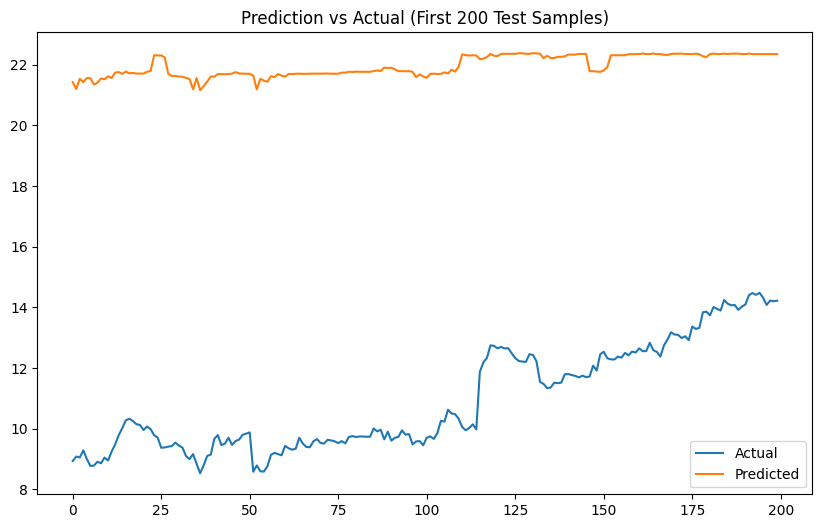

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")
plt.legend()
plt.title("Prediction vs Actual (First 200 Test Samples)")
plt.show()

In [ ]:
df = df.sort_values(["Symbol", "Date"])

df["Return"] = df.groupby("Symbol")["Close"].pct_change()
df["Target"] = df.groupby("Symbol")["Return"].shift(-1)

df.dropna(inplace=True)
df.head()

Price,Date,Open,High,Low,Close,Volume,Symbol,RSI,EMA_20,EMA_50,MACD,MACD_Signal,Next_Close,Return,Target
50,2016-05-05,21.418781,21.434731,21.118007,21.245607,143562000,AAPL,25.086668,22.835681,23.184394,-0.764956,-0.429800,21.127125,-0.004059,-0.005577
51,2016-05-06,21.275234,21.293461,20.928886,21.127125,174799600,AAPL,24.299686,22.672961,23.103717,-0.800270,-0.503894,21.143072,-0.005577,0.000755
52,2016-05-09,21.190922,21.366373,21.097499,21.143072,131745600,AAPL,24.642349,22.527258,23.026829,-0.817546,-0.566624,21.286623,0.000755,0.006789
53,2016-05-10,21.266116,21.320802,20.988128,21.286623,134747200,AAPL,27.810082,22.409102,22.958585,-0.810314,-0.615362,21.079273,0.006789,-0.009741
54,2016-05-11,21.300297,21.320804,21.067880,21.079273,114876400,AAPL,26.103223,22.282452,22.884887,-0.811953,-0.654680,20.584812,-0.009741,-0.023457


In [ ]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_train = features.iloc[:train_size]
y_train = target.iloc[:train_size]

X_val = features.iloc[train_size:train_size+val_size]
y_val = target.iloc[train_size:train_size+val_size]

X_test = features.iloc[train_size+val_size:]
y_test = target.iloc[train_size+val_size:]

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 8617
Val: 1846
Test: 1857


In [ ]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X, y, name):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)

    direction_acc = np.mean(np.sign(preds) == np.sign(y))

    print(f"\n{name} Results")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print("Directional Accuracy:", direction_acc)

evaluate(model, X_val, y_val, "Validation")
evaluate(model, X_test, y_test, "Test")


Validation Results
MAE: 78.47505174393515
RMSE: 148.39119995683103
R²: 0.60904047293581
Directional Accuracy: 1.0

Test Results
MAE: 1.1675208768911367
RMSE: 1.733502571412313
R²: 0.995919743993019
Directional Accuracy: 1.0


In [ ]:
rolling_predictions = []
rolling_actuals = []

window = train_size

for i in range(window, len(df)-1):
    X_train_roll = features.iloc[:i]
    y_train_roll = target.iloc[:i]

    X_test_roll = features.iloc[i:i+1]
    y_test_roll = target.iloc[i:i+1]

    model.fit(X_train_roll, y_train_roll)
    pred = model.predict(X_test_roll)

    rolling_predictions.append(pred[0])
    rolling_actuals.append(y_test_roll.values[0])

rolling_predictions = np.array(rolling_predictions)
rolling_actuals = np.array(rolling_actuals)

print("Rolling Directional Accuracy:",
      np.mean(np.sign(rolling_predictions) == np.sign(rolling_actuals)))

NameError: name 'train_size' is not defined